In [4]:
import os
import copy
import math
import time
import json
import warnings
import random
from pathlib import Path

import cv2
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision import models as tv_models

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

In [5]:
# DATASET PATHS
TRAIN_CSV = "splits_final/train.csv"
VAL_CSV = "splits_final/val.csv"
TEST_CSV = "splits_final/test.csv"
STRESS_CSV = "splits_final/stress_test.csv"

BASE_OUTPUT_DIR = "model_outputs_updated"

# TRAINING CONFIGURATION
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 100
PATIENCE = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
THRESHOLD = 0.5
SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# All models
MODEL_LIST = [
    "resnet50",
    "resnet101",
    "densenet121",
    "efficientnet_b0",
    "efficientnet_b3",
    "mobilenet_v3_large",
    "convnext_tiny",
    "vgg16",
]

In [3]:
# only running ResNet50
SELECTED_MODELS = ["resnet50"]

#SELECTED_MODELS = MODEL_LIST

os.makedirs(BASE_OUTPUT_DIR, exist_ok=True)

print("Using device:", DEVICE)
print("Selected models:", SELECTED_MODELS)

Using device: cuda
Selected models: ['resnet50']


In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
torch.backends.cudnn.benchmark = True

In [5]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)
stress_df = pd.read_csv(STRESS_CSV)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))
print("Stress:", len(stress_df))

print("\nTrain label counts:")
print(train_df["binary_label"].value_counts().sort_index())

print("\nVal label counts:")
print(val_df["binary_label"].value_counts().sort_index())

print("\nTest label counts:")
print(test_df["binary_label"].value_counts().sort_index())

Train: 1343
Val: 288
Test: 289
Stress: 302

Train label counts:
binary_label
0    705
1    638
Name: count, dtype: int64

Val label counts:
binary_label
0    151
1    137
Name: count, dtype: int64

Test label counts:
binary_label
0    151
1    138
Name: count, dtype: int64


In [6]:
train_label_counts = train_df["binary_label"].value_counts().to_dict()
num_neg = train_label_counts.get(0, 0)
num_pos = train_label_counts.get(1, 0)

pos_weight_value = num_neg / num_pos if num_pos > 0 else 1.0
print("Negative:", num_neg)
print("Positive:", num_pos)
print("pos_weight:", pos_weight_value)

Negative: 705
Positive: 638
pos_weight: 1.1050156739811912


In [7]:
class TornadoBinaryDataset(Dataset):
    def __init__(self, df, transform=None, require_label=True):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.require_label = require_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        while True:
            row = self.df.iloc[idx]
            img_path = row["filepath"]
            subclass = row.get("subclass", "unknown")

            try:
                image = Image.open(img_path).convert("RGB")
                break
            except Exception:
                # Skip corrupted image
                idx = (idx + 1) % len(self.df)

        if self.transform is not None:
            image = self.transform(image)

        if self.require_label:
            label = float(row["binary_label"])
            return {
                "image": image,
                "label": torch.tensor(label, dtype=torch.float32),
                "filepath": img_path,
                "subclass": subclass
            }
        else:
            return {
                "image": image,
                "filepath": img_path,
                "subclass": subclass
            }

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
train_dataset = TornadoBinaryDataset(train_df, transform=train_transform, require_label=True)
val_dataset = TornadoBinaryDataset(val_df, transform=eval_transform, require_label=True)
test_dataset = TornadoBinaryDataset(test_df, transform=eval_transform, require_label=True)
stress_dataset = TornadoBinaryDataset(stress_df, transform=eval_transform, require_label=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
stress_loader = DataLoader(
    stress_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print("DataLoaders ready.")

DataLoaders ready.


In [10]:
def build_model(model_name):
    if model_name == "resnet50":
        from torchvision.models import resnet50, ResNet50_Weights
        model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    elif model_name == "resnet101":
        from torchvision.models import resnet101, ResNet101_Weights
        model = resnet101(weights=ResNet101_Weights.IMAGENET1K_V2)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    elif model_name == "densenet121":
        from torchvision.models import densenet121, DenseNet121_Weights
        model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        in_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    elif model_name == "efficientnet_b0":
        from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    elif model_name == "efficientnet_b3":
        from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
        model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    elif model_name == "mobilenet_v3_large":
        from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
        model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2)
        in_features = model.classifier[3].in_features
        model.classifier = nn.Sequential(
            nn.Linear(model.classifier[0].in_features, model.classifier[0].out_features),
            nn.Hardswish(),
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    elif model_name == "convnext_tiny":
        from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
        model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        in_features = model.classifier[2].in_features
        model.classifier = nn.Sequential(
            model.classifier[0],
            model.classifier[1],
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    elif model_name == "vgg16":
        from torchvision.models import vgg16, VGG16_Weights
        model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    else:
        raise ValueError(f"Unsupported model: {model_name}")

    return model

In [11]:
def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (np.array(y_prob) >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        metrics["roc_auc"] = np.nan

    metrics["confusion_matrix"] = confusion_matrix(y_true, y_pred)
    return metrics, y_pred

In [12]:
#TRAIN AND EVALUATE

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    y_true, y_prob = [], []

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(logits).detach().cpu().numpy().flatten()
        y_prob.extend(probs.tolist())
        y_true.extend(labels.detach().cpu().numpy().flatten().tolist())

    metrics, _ = compute_binary_metrics(y_true, y_prob, threshold=THRESHOLD)
    metrics["loss"] = running_loss / len(loader)
    return metrics


def evaluate_labeled(model, loader, criterion, device, threshold=0.5):
    model.eval()
    running_loss = 0.0
    y_true, y_prob = [], []
    filepaths, subclasses = [], []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True).unsqueeze(1)

            logits = model(images)
            loss = criterion(logits, labels)
            running_loss += loss.item()

            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            y_prob.extend(probs.tolist())
            y_true.extend(labels.cpu().numpy().flatten().tolist())
            filepaths.extend(batch["filepath"])
            subclasses.extend(batch["subclass"])

    metrics, y_pred = compute_binary_metrics(y_true, y_prob, threshold=threshold)
    metrics["loss"] = running_loss / len(loader)

    pred_df = pd.DataFrame({
        "filepath": filepaths,
        "subclass": subclasses,
        "true_label": y_true,
        "pred_prob": y_prob,
        "pred_label": y_pred
    })
    return metrics, pred_df


def evaluate_unlabeled(model, loader, device, threshold=0.5):
    model.eval()
    filepaths, subclasses, probs, preds = [], [], [], []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device, non_blocking=True)
            logits = model(images)
            batch_probs = torch.sigmoid(logits).cpu().numpy().flatten()
            batch_preds = (batch_probs >= threshold).astype(int)

            probs.extend(batch_probs.tolist())
            preds.extend(batch_preds.tolist())
            filepaths.extend(batch["filepath"])
            subclasses.extend(batch["subclass"])

    df = pd.DataFrame({
        "filepath": filepaths,
        "subclass": subclasses,
        "pred_prob": probs,
        "pred_label": preds
    })
    return df

In [13]:
#SUBCLASS FP

def subclass_false_positive_analysis(pred_df):
    non_tornado_df = pred_df[pred_df["true_label"] == 0].copy()
    rows = []

    for subclass, group in non_tornado_df.groupby("subclass"):
        total = len(group)
        fps = int((group["pred_label"] == 1).sum())
        fp_rate = fps / total if total > 0 else 0.0
        rows.append({
            "subclass": subclass,
            "total_non_tornado_samples": total,
            "false_positives": fps,
            "false_positive_rate": fp_rate
        })

    return pd.DataFrame(rows).sort_values("false_positive_rate", ascending=False)

#THRESHOLD SWEEP HAS NOT BEEN INCLUDeD IN THE PAPER YET
def threshold_sweep(pred_df, thresholds=(0.3, 0.4, 0.5, 0.6, 0.7)):
    y_true = pred_df["true_label"].values
    y_prob = pred_df["pred_prob"].values

    rows = []
    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)
        rows.append({
            "threshold": th,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        })

    return pd.DataFrame(rows)

In [14]:
#PLOTTING CURVES 

def plot_training_curves(history_df, output_dir, model_name):
    if history_df.empty:
        print(f"No history found for {model_name}, skipping plots.")
        return

    # Train loss vs val loss
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Training Loss vs Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "loss_curve.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # Train acc vs val accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
    plt.plot(history_df["epoch"], history_df["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Training Accuracy vs Validation Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "accuracy_curve.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # 3. Train F1 vs val F1
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_f1"], label="Train F1")
    plt.plot(history_df["epoch"], history_df["val_f1"], label="Validation F1")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.title(f"{model_name} Training F1 vs Validation F1")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "f1_curve.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # 4. Precision and Recall vs epoch
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_precision"], label="Train Precision")
    plt.plot(history_df["epoch"], history_df["val_precision"], label="Validation Precision")
    plt.plot(history_df["epoch"], history_df["train_recall"], label="Train Recall")
    plt.plot(history_df["epoch"], history_df["val_recall"], label="Validation Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"{model_name} Precision and Recall vs Epoch")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "precision_recall_curve.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

In [15]:
def run_single_model(model_name):
    print(f"\n{'='*60}")
    print(f"Running model: {model_name}")
    print(f"{'='*60}")

    output_dir = os.path.join(BASE_OUTPUT_DIR, model_name)
    os.makedirs(output_dir, exist_ok=True)

    model = build_model(model_name).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)
    )

    optimizer = optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = np.inf
    best_epoch = -1
    best_train_metrics = None
    best_val_metrics = None
    patience_counter = 0
    history = []

    for epoch in range(EPOCHS):
        epoch_idx = epoch + 1

        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_metrics, val_pred_df = evaluate_labeled(
            model, val_loader, criterion, DEVICE, threshold=THRESHOLD
        )

        row = {
            "epoch": epoch_idx,
            "lr": optimizer.param_groups[0]["lr"],

            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["accuracy"],
            "train_precision": train_metrics["precision"],
            "train_recall": train_metrics["recall"],
            "train_f1": train_metrics["f1"],
            "train_roc_auc": train_metrics["roc_auc"],

            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_roc_auc": val_metrics["roc_auc"],
        }
        history.append(row)

        print(
            f"Epoch {epoch_idx:03d} | "
            f"LR {optimizer.param_groups[0]['lr']:.6f} | "
            f"Train Loss {train_metrics['loss']:.4f} | Train Acc {train_metrics['accuracy']:.4f} | "
            f"Train F1 {train_metrics['f1']:.4f} | "
            f"Val Loss {val_metrics['loss']:.4f} | Val Acc {val_metrics['accuracy']:.4f} | "
            f"Val F1 {val_metrics['f1']:.4f}"
        )

        # Early stopping on validation loss
        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch_idx
            best_state = copy.deepcopy(model.state_dict())
            best_train_metrics = copy.deepcopy(train_metrics)
            best_val_metrics = copy.deepcopy(val_metrics)
            patience_counter = 0

            torch.save(best_state, os.path.join(output_dir, f"best_{model_name}.pth"))
            val_pred_df.to_csv(os.path.join(output_dir, "best_val_predictions.csv"), index=False)
        else:
            patience_counter += 1

        scheduler.step()

        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch_idx}")
            break

    # Save full training history
    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(output_dir, "training_log.csv"), index=False)

    # Plot curves for all epochs that were run
    plot_training_curves(history_df, output_dir, model_name)

    # Load best model
    model.load_state_dict(best_state)

    # Full test evaluation
    test_metrics, test_pred_df = evaluate_labeled(
        model, test_loader, criterion, DEVICE, threshold=THRESHOLD
    )
    test_pred_df.to_csv(os.path.join(output_dir, "test_predictions.csv"), index=False)

    # Subclass FP
    subclass_fp_df = subclass_false_positive_analysis(test_pred_df)
    subclass_fp_df.to_csv(os.path.join(output_dir, "subclass_false_positive_analysis.csv"), index=False)

    # Threshold sweep has not been mentioned in the paper yet
    threshold_df = threshold_sweep(test_pred_df)
    threshold_df.to_csv(os.path.join(output_dir, "threshold_sweep.csv"), index=False)

    # Stress test
    stress_pred_df = evaluate_unlabeled(model, stress_loader, DEVICE, threshold=THRESHOLD)
    stress_pred_df.to_csv(os.path.join(output_dir, "stress_test_predictions.csv"), index=False)

    # Summary
    summary = {
        "model": model_name,
        "best_epoch": best_epoch,

        "best_train_loss": best_train_metrics["loss"] if best_train_metrics else None,
        "best_train_accuracy": best_train_metrics["accuracy"] if best_train_metrics else None,
        "best_train_precision": best_train_metrics["precision"] if best_train_metrics else None,
        "best_train_recall": best_train_metrics["recall"] if best_train_metrics else None,
        "best_train_f1": best_train_metrics["f1"] if best_train_metrics else None,
        "best_train_roc_auc": best_train_metrics["roc_auc"] if best_train_metrics else None,

        "best_val_loss": best_val_metrics["loss"] if best_val_metrics else None,
        "best_val_accuracy": best_val_metrics["accuracy"] if best_val_metrics else None,
        "best_val_precision": best_val_metrics["precision"] if best_val_metrics else None,
        "best_val_recall": best_val_metrics["recall"] if best_val_metrics else None,
        "best_val_f1": best_val_metrics["f1"] if best_val_metrics else None,
        "best_val_roc_auc": best_val_metrics["roc_auc"] if best_val_metrics else None,

        "test_loss": test_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "test_roc_auc": test_metrics["roc_auc"],
        "tn_fp_fn_tp": test_metrics["confusion_matrix"].tolist(),
        "num_parameters": sum(p.numel() for p in model.parameters()),
    }

    with open(os.path.join(output_dir, "final_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    with open(os.path.join(output_dir, "final_summary.txt"), "w") as f:
        f.write(f"Model: {model_name}\n")
        f.write(f"Best Epoch: {best_epoch}\n\n")

        f.write("Best Train Metrics:\n")
        f.write(f"Train Loss: {summary['best_train_loss']:.4f}\n" if summary["best_train_loss"] is not None else "Train Loss: None\n")
        f.write(f"Train Accuracy: {summary['best_train_accuracy']:.4f}\n" if summary["best_train_accuracy"] is not None else "Train Accuracy: None\n")
        f.write(f"Train Precision: {summary['best_train_precision']:.4f}\n" if summary["best_train_precision"] is not None else "Train Precision: None\n")
        f.write(f"Train Recall: {summary['best_train_recall']:.4f}\n" if summary["best_train_recall"] is not None else "Train Recall: None\n")
        f.write(f"Train F1: {summary['best_train_f1']:.4f}\n" if summary["best_train_f1"] is not None else "Train F1: None\n")
        f.write(f"Train ROC-AUC: {summary['best_train_roc_auc']:.4f}\n\n" if summary["best_train_roc_auc"] is not None else "Train ROC-AUC: None\n\n")

        f.write("Best Validation Metrics:\n")
        f.write(f"Val Loss: {summary['best_val_loss']:.4f}\n" if summary["best_val_loss"] is not None else "Val Loss: None\n")
        f.write(f"Val Accuracy: {summary['best_val_accuracy']:.4f}\n" if summary["best_val_accuracy"] is not None else "Val Accuracy: None\n")
        f.write(f"Val Precision: {summary['best_val_precision']:.4f}\n" if summary["best_val_precision"] is not None else "Val Precision: None\n")
        f.write(f"Val Recall: {summary['best_val_recall']:.4f}\n" if summary["best_val_recall"] is not None else "Val Recall: None\n")
        f.write(f"Val F1: {summary['best_val_f1']:.4f}\n" if summary["best_val_f1"] is not None else "Val F1: None\n")
        f.write(f"Val ROC-AUC: {summary['best_val_roc_auc']:.4f}\n\n" if summary["best_val_roc_auc"] is not None else "Val ROC-AUC: None\n\n")

        f.write("Test Metrics:\n")
        f.write(f"Test Loss: {test_metrics['loss']:.4f}\n")
        f.write(f"Test Accuracy: {test_metrics['accuracy']:.4f}\n")
        f.write(f"Test Precision: {test_metrics['precision']:.4f}\n")
        f.write(f"Test Recall: {test_metrics['recall']:.4f}\n")
        f.write(f"Test F1: {test_metrics['f1']:.4f}\n")
        f.write(f"Test ROC-AUC: {test_metrics['roc_auc']:.4f}\n")
        f.write(f"Confusion Matrix:\n{test_metrics['confusion_matrix']}\n\n")

        f.write("Classification Report:\n")
        f.write(classification_report(
            test_pred_df["true_label"],
            test_pred_df["pred_label"],
            target_names=["non-tornado", "tornado"],
            digits=4
        ))

    print("\nFinal test metrics:")
    print(summary)

    return summary


Running model: resnet50
Epoch 001 | LR 0.000100 | Train Loss 0.5366 | Train Acc 0.7945 | Train F1 0.7943 | Val Loss 0.2304 | Val Acc 0.9479 | Val F1 0.9455
Epoch 002 | LR 0.000100 | Train Loss 0.1700 | Train Acc 0.9576 | Train F1 0.9559 | Val Loss 0.1570 | Val Acc 0.9410 | Val F1 0.9399
Epoch 003 | LR 0.000100 | Train Loss 0.0625 | Train Acc 0.9844 | Train F1 0.9835 | Val Loss 0.1017 | Val Acc 0.9618 | Val F1 0.9603
Epoch 004 | LR 0.000100 | Train Loss 0.0328 | Train Acc 0.9926 | Train F1 0.9922 | Val Loss 0.1377 | Val Acc 0.9410 | Val F1 0.9391
Epoch 005 | LR 0.000100 | Train Loss 0.0230 | Train Acc 0.9970 | Train F1 0.9969 | Val Loss 0.0978 | Val Acc 0.9722 | Val F1 0.9708
Epoch 006 | LR 0.000099 | Train Loss 0.0093 | Train Acc 0.9993 | Train F1 0.9992 | Val Loss 0.1079 | Val Acc 0.9722 | Val F1 0.9708
Epoch 007 | LR 0.000099 | Train Loss 0.0289 | Train Acc 0.9926 | Train F1 0.9921 | Val Loss 0.1902 | Val Acc 0.9618 | Val F1 0.9603
Epoch 008 | LR 0.000099 | Train Loss 0.0425 | Train

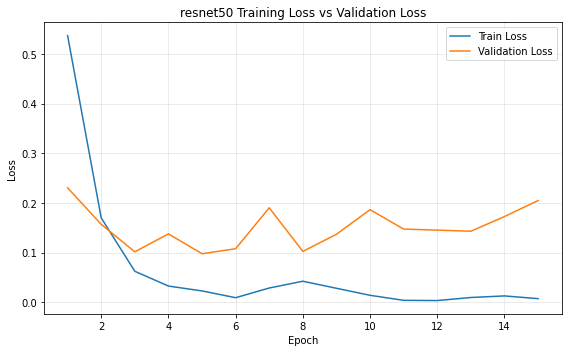

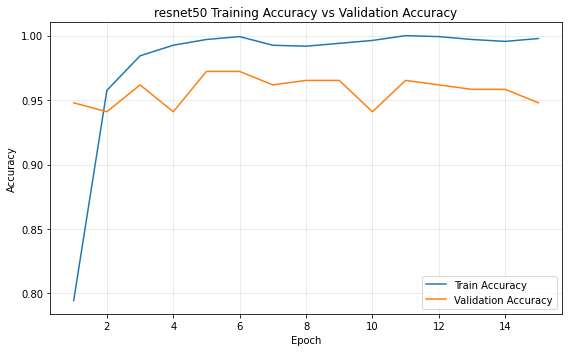

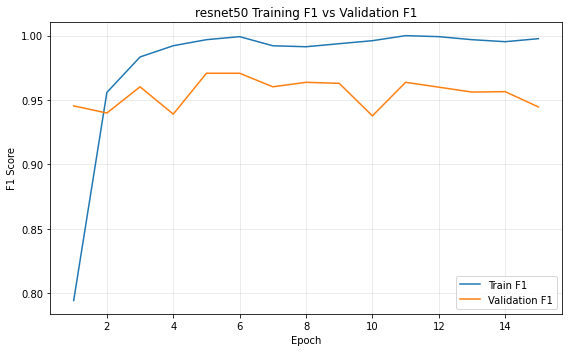

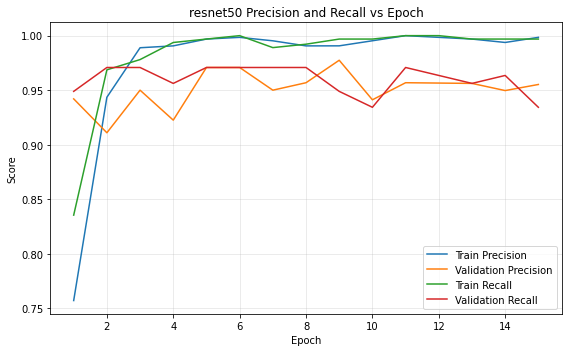


Final test metrics:
{'model': 'resnet50', 'best_epoch': 5, 'best_train_loss': 0.022989291387299698, 'best_train_accuracy': 0.9970215934475056, 'best_train_precision': 0.9968652037617555, 'best_train_recall': 0.9968652037617555, 'best_train_f1': 0.9968652037617555, 'best_train_roc_auc': np.float64(0.9997421018697614), 'best_val_loss': 0.09784021849433581, 'best_val_accuracy': 0.9722222222222222, 'best_val_precision': 0.9708029197080292, 'best_val_recall': 0.9708029197080292, 'best_val_f1': 0.9708029197080292, 'best_val_roc_auc': np.float64(0.9916130903465945), 'test_loss': 0.042532480246154594, 'test_accuracy': 0.9826989619377162, 'test_precision': 0.9784172661870504, 'test_recall': 0.9855072463768116, 'test_f1': 0.9819494584837545, 'test_roc_auc': np.float64(0.9989922257414339), 'tn_fp_fn_tp': [[148, 3], [2, 136]], 'num_parameters': 23510081}

Running model: resnet101
Epoch 001 | LR 0.000100 | Train Loss 0.5060 | Train Acc 0.8004 | Train F1 0.8006 | Val Loss 0.2189 | Val Acc 0.9444 | 

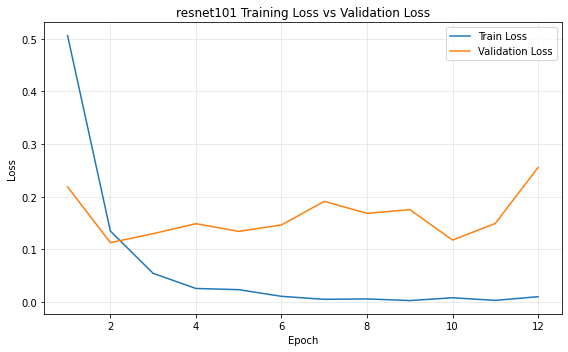

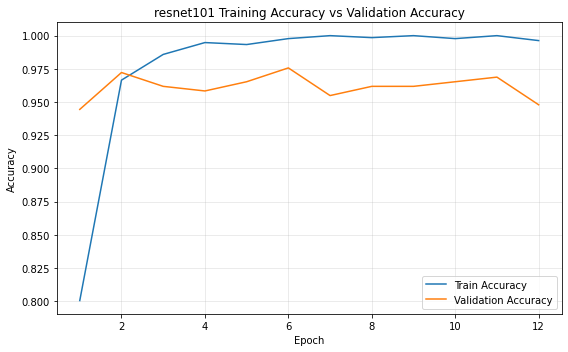

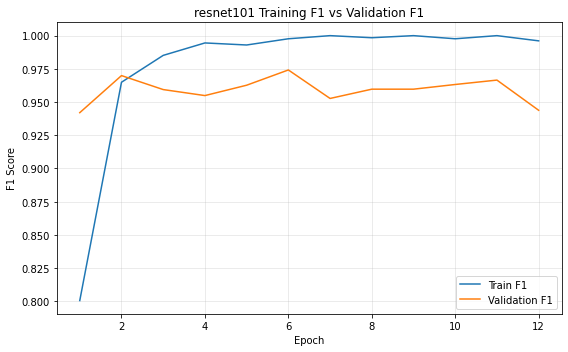

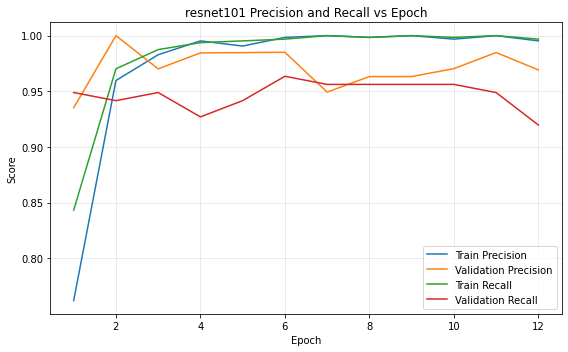


Final test metrics:
{'model': 'resnet101', 'best_epoch': 2, 'best_train_loss': 0.1350335901869195, 'best_train_accuracy': 0.9664929262844378, 'best_train_precision': 0.9596899224806201, 'best_train_recall': 0.9702194357366771, 'best_train_f1': 0.9649259547934529, 'best_train_roc_auc': np.float64(0.9928188710287024), 'best_val_loss': 0.11295628630452687, 'best_val_accuracy': 0.9722222222222222, 'best_val_precision': 1.0, 'best_val_recall': 0.9416058394160584, 'best_val_f1': 0.9699248120300752, 'best_val_roc_auc': np.float64(0.9938850485812345), 'test_loss': 0.09559928551316262, 'test_accuracy': 0.9619377162629758, 'test_precision': 0.9774436090225563, 'test_recall': 0.9420289855072463, 'test_f1': 0.959409594095941, 'test_roc_auc': np.float64(0.9946252039543142), 'tn_fp_fn_tp': [[148, 3], [8, 130]], 'num_parameters': 42502209}

Running model: densenet121
Epoch 001 | LR 0.000100 | Train Loss 0.3969 | Train Acc 0.8273 | Train F1 0.8196 | Val Loss 0.1661 | Val Acc 0.9514 | Val F1 0.9489
Ep

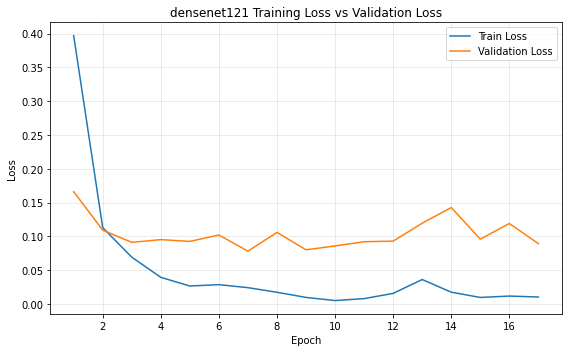

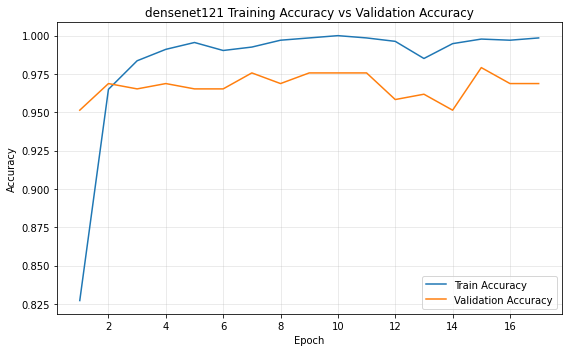

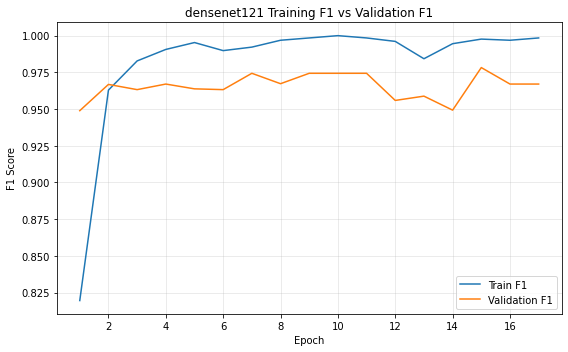

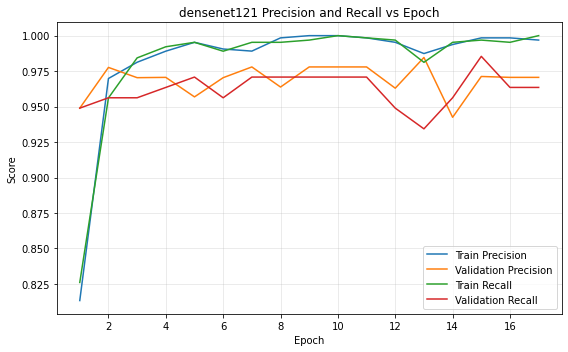


Final test metrics:
{'model': 'densenet121', 'best_epoch': 7, 'best_train_loss': 0.024078739313630478, 'best_train_accuracy': 0.992553983618764, 'best_train_precision': 0.9890965732087228, 'best_train_recall': 0.9952978056426333, 'best_train_f1': 0.9921875, 'best_train_roc_auc': np.float64(0.9997932368438605), 'best_val_loss': 0.07805934527681933, 'best_val_accuracy': 0.9756944444444444, 'best_val_precision': 0.9779411764705882, 'best_val_recall': 0.9708029197080292, 'best_val_f1': 0.9743589743589743, 'best_val_roc_auc': np.float64(0.9960119882051529), 'test_loss': 0.06681349647387833, 'test_accuracy': 0.9653979238754326, 'test_precision': 0.9705882352941176, 'test_recall': 0.9565217391304348, 'test_f1': 0.9635036496350365, 'test_roc_auc': np.float64(0.997360591227565), 'tn_fp_fn_tp': [[147, 4], [6, 132]], 'num_parameters': 6954881}

Running model: efficientnet_b0
Epoch 001 | LR 0.000100 | Train Loss 0.5962 | Train Acc 0.7424 | Train F1 0.7580 | Val Loss 0.3901 | Val Acc 0.8819 | Val 

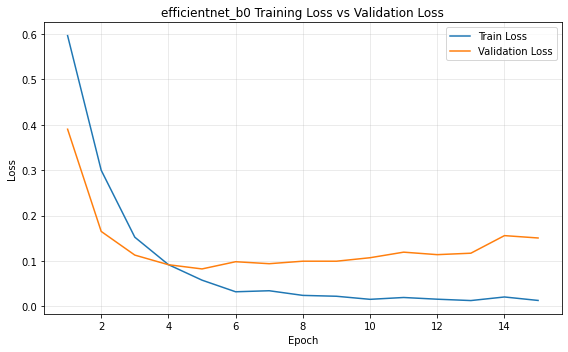

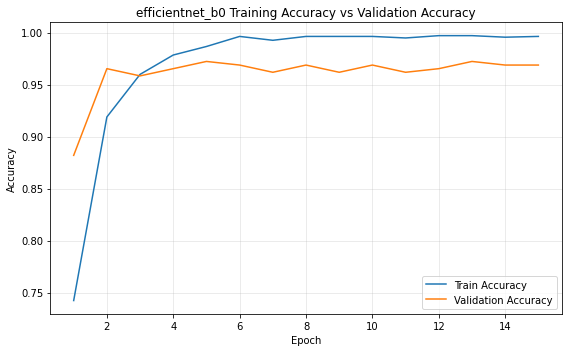

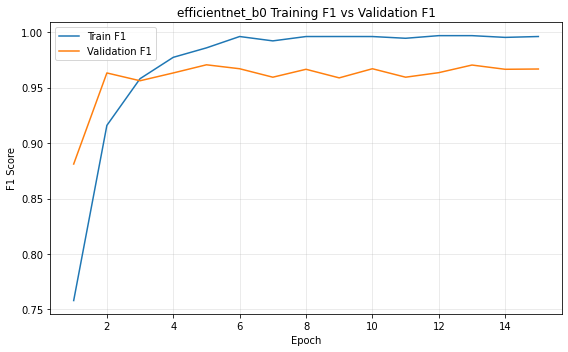

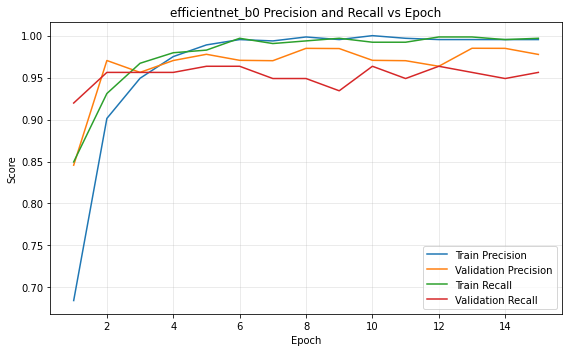


Final test metrics:
{'model': 'efficientnet_b0', 'best_epoch': 5, 'best_train_loss': 0.057758587501233534, 'best_train_accuracy': 0.9865971705137752, 'best_train_precision': 0.9889589905362776, 'best_train_recall': 0.9827586206896551, 'best_train_f1': 0.9858490566037735, 'best_train_roc_auc': np.float64(0.999290780141844), 'best_val_loss': 0.0824868194758892, 'best_val_accuracy': 0.9722222222222222, 'best_val_precision': 0.9777777777777777, 'best_val_recall': 0.9635036496350365, 'best_val_f1': 0.9705882352941176, 'best_val_roc_auc': np.float64(0.9969304394063906), 'test_loss': 0.07088848318671807, 'test_accuracy': 0.9757785467128027, 'test_precision': 0.9781021897810219, 'test_recall': 0.9710144927536232, 'test_f1': 0.9745454545454545, 'test_roc_auc': np.float64(0.996880698723486), 'tn_fp_fn_tp': [[148, 3], [4, 134]], 'num_parameters': 4008829}

Running model: efficientnet_b3
Epoch 001 | LR 0.000100 | Train Loss 0.6295 | Train Acc 0.7305 | Train F1 0.7315 | Val Loss 0.4684 | Val Acc 0

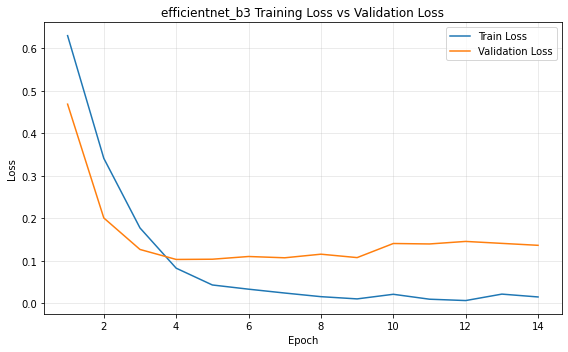

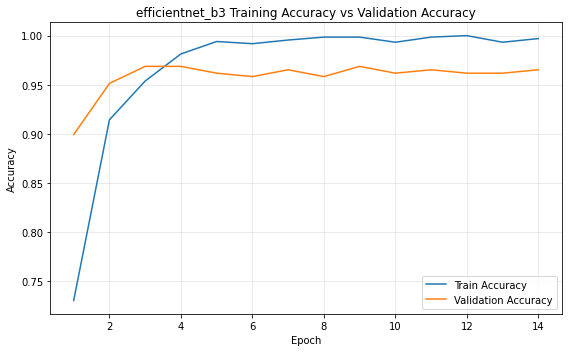

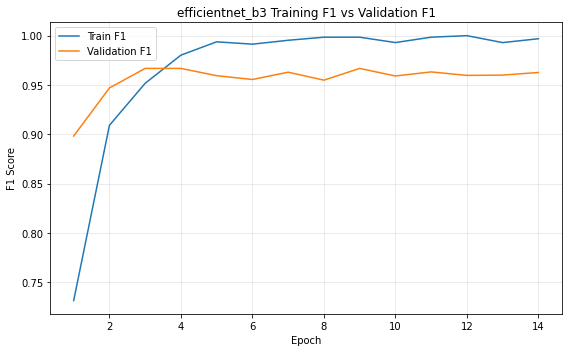

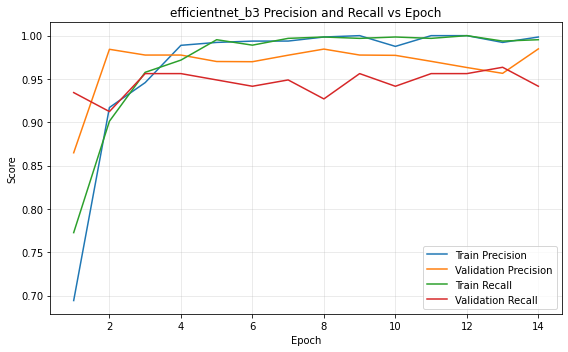


Final test metrics:
{'model': 'efficientnet_b3', 'best_epoch': 4, 'best_train_loss': 0.0825927307208379, 'best_train_accuracy': 0.9813849590469099, 'best_train_precision': 0.988835725677831, 'best_train_recall': 0.9717868338557993, 'best_train_f1': 0.9802371541501976, 'best_train_roc_auc': np.float64(0.9979546010360391), 'best_val_loss': 0.10312007284826702, 'best_val_accuracy': 0.96875, 'best_val_precision': 0.9776119402985075, 'best_val_recall': 0.9562043795620438, 'best_val_f1': 0.966789667896679, 'best_val_roc_auc': np.float64(0.9941750858026781), 'test_loss': 0.0903577812248841, 'test_accuracy': 0.9653979238754326, 'test_precision': 0.9776119402985075, 'test_recall': 0.9492753623188406, 'test_f1': 0.9632352941176471, 'test_roc_auc': np.float64(0.995297053460025), 'tn_fp_fn_tp': [[148, 3], [7, 131]], 'num_parameters': 10697769}

Running model: mobilenet_v3_large
Epoch 001 | LR 0.000100 | Train Loss 0.4961 | Train Acc 0.7937 | Train F1 0.7666 | Val Loss 0.2115 | Val Acc 0.9410 | Va

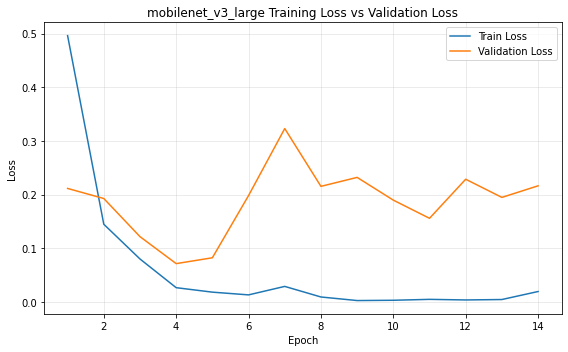

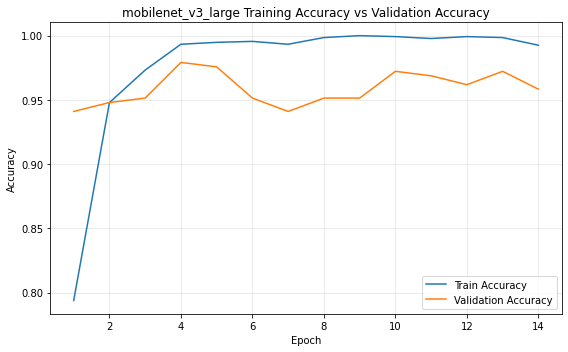

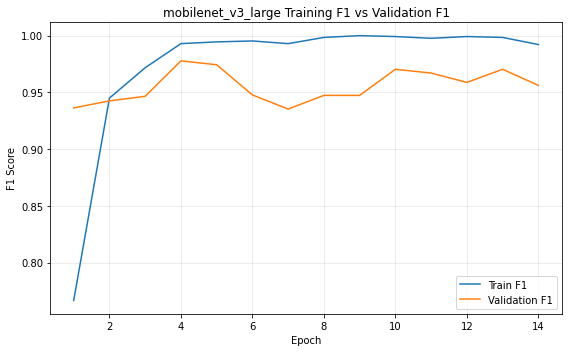

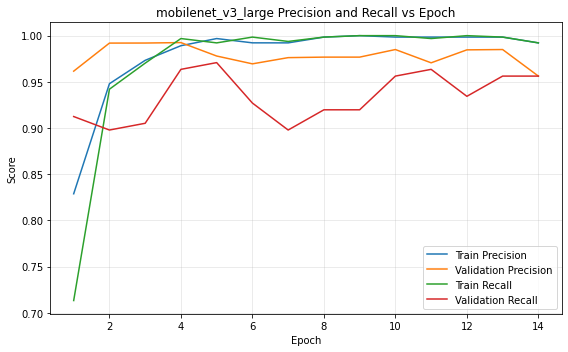


Final test metrics:
{'model': 'mobilenet_v3_large', 'best_epoch': 4, 'best_train_loss': 0.026601273633007492, 'best_train_accuracy': 0.9932985852568875, 'best_train_precision': 0.9891135303265941, 'best_train_recall': 0.9968652037617555, 'best_train_f1': 0.9929742388758782, 'best_train_roc_auc': np.float64(0.9996665110384847), 'best_val_loss': 0.07142672661898865, 'best_val_accuracy': 0.9791666666666666, 'best_val_precision': 0.9924812030075187, 'best_val_recall': 0.9635036496350365, 'best_val_f1': 0.9777777777777777, 'best_val_roc_auc': np.float64(0.9976555324599989), 'test_loss': 0.09624122273227158, 'test_accuracy': 0.9688581314878892, 'test_precision': 0.9777777777777777, 'test_recall': 0.9565217391304348, 'test_f1': 0.967032967032967, 'test_roc_auc': np.float64(0.9944332469526825), 'tn_fp_fn_tp': [[148, 3], [6, 132]], 'num_parameters': 4203313}

Running model: convnext_tiny
Epoch 001 | LR 0.000100 | Train Loss 0.3245 | Train Acc 0.8608 | Train F1 0.8618 | Val Loss 0.1787 | Val Ac

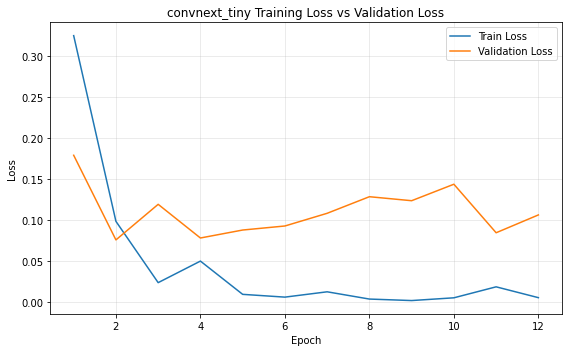

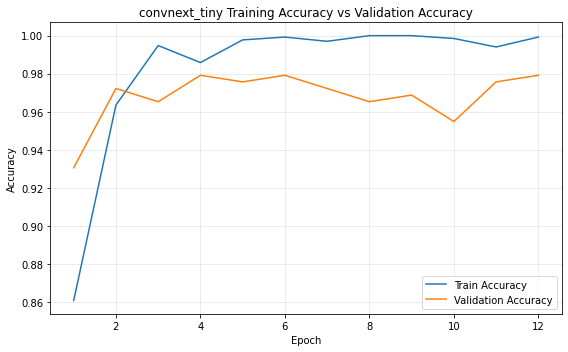

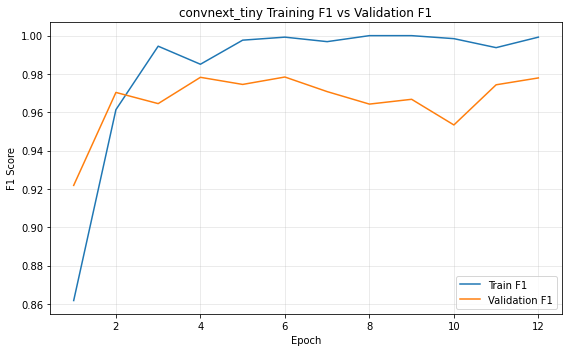

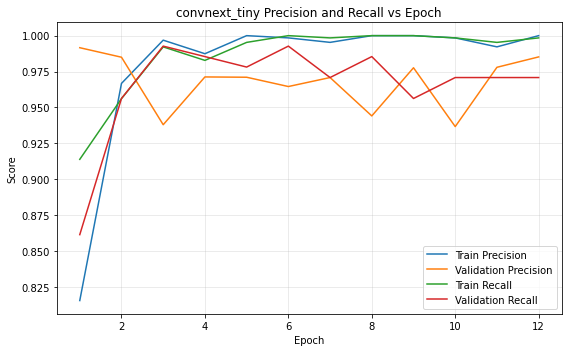


Final test metrics:
{'model': 'convnext_tiny', 'best_epoch': 2, 'best_train_loss': 0.09820520718182836, 'best_train_accuracy': 0.9635145197319435, 'best_train_precision': 0.9667194928684627, 'best_train_recall': 0.9561128526645768, 'best_train_f1': 0.9613869188337274, 'best_train_roc_auc': np.float64(0.9954356477467262), 'best_val_loss': 0.0755735816847947, 'best_val_accuracy': 0.9722222222222222, 'best_val_precision': 0.9849624060150376, 'best_val_recall': 0.9562043795620438, 'best_val_f1': 0.9703703703703703, 'best_val_roc_auc': np.float64(0.997848890607628), 'test_loss': 0.053657165612094104, 'test_accuracy': 0.972318339100346, 'test_precision': 0.9850746268656716, 'test_recall': 0.9565217391304348, 'test_f1': 0.9705882352941176, 'test_roc_auc': np.float64(0.9982723869853153), 'tn_fp_fn_tp': [[149, 2], [6, 132]], 'num_parameters': 27820897}

Running model: vgg16
Epoch 001 | LR 0.000100 | Train Loss 0.4215 | Train Acc 0.8243 | Train F1 0.8162 | Val Loss 0.2288 | Val Acc 0.8958 | Val

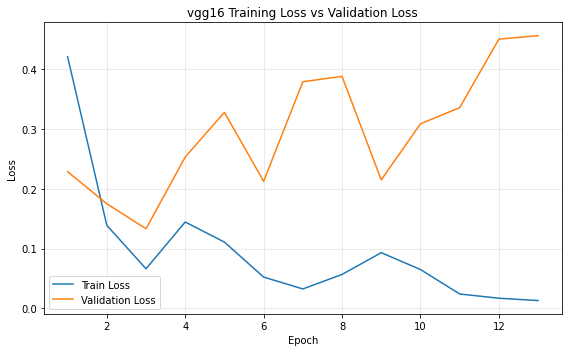

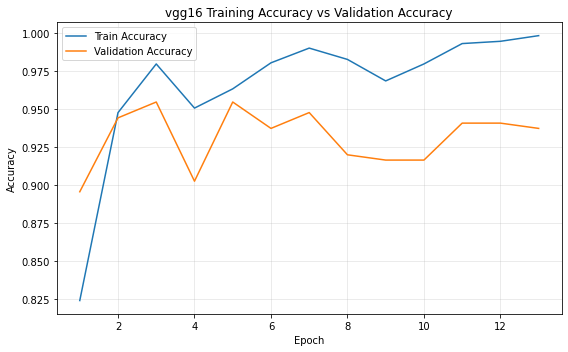

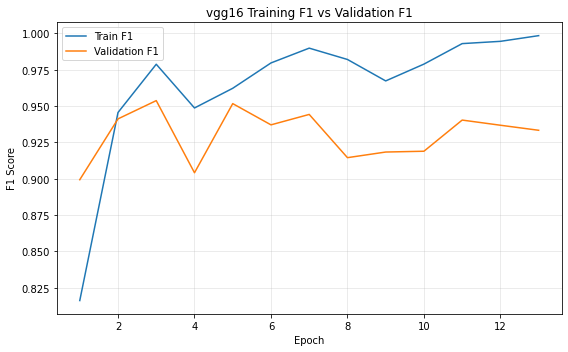

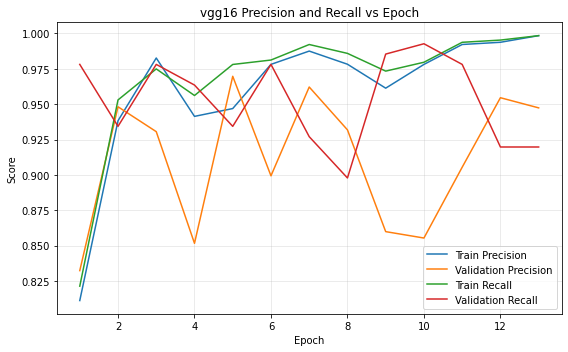


Final test metrics:
{'model': 'vgg16', 'best_epoch': 3, 'best_train_loss': 0.06633625230530188, 'best_train_accuracy': 0.9798957557706627, 'best_train_precision': 0.9826224328593997, 'best_train_recall': 0.9749216300940439, 'best_train_f1': 0.978756884343037, 'best_train_roc_auc': np.float64(0.9969919295671315), 'best_val_loss': 0.13334331495894325, 'best_val_accuracy': 0.9548611111111112, 'best_val_precision': 0.9305555555555556, 'best_val_recall': 0.9781021897810219, 'best_val_f1': 0.9537366548042705, 'best_val_roc_auc': np.float64(0.9907913182191714), 'test_loss': 0.13611666516691265, 'test_accuracy': 0.9480968858131488, 'test_precision': 0.9300699300699301, 'test_recall': 0.9637681159420289, 'test_f1': 0.9466192170818505, 'test_roc_auc': np.float64(0.9900662251655628), 'tn_fp_fn_tp': [[141, 10], [5, 133]], 'num_parameters': 134264641}


,model,best_epoch,best_train_loss,best_train_accuracy,best_train_precision,best_train_recall,best_train_f1,best_train_roc_auc,best_val_loss,best_val_accuracy,...,best_val_f1,best_val_roc_auc,test_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,tn_fp_fn_tp,num_parameters
0,resnet50,5,0.022989,0.997022,0.996865,0.996865,0.996865,0.999742,0.097840,0.972222,...,0.970803,0.991613,0.042532,0.982699,0.978417,0.985507,0.981949,0.998992,"[[148, 3], [2, 136]]",23510081
1,resnet101,2,0.135034,0.966493,0.959690,0.970219,0.964926,0.992819,0.112956,0.972222,...,0.969925,0.993885,0.095599,0.961938,0.977444,0.942029,0.959410,0.994625,"[[148, 3], [8, 130]]",42502209
2,densenet121,7,0.024079,0.992554,0.989097,0.995298,0.992188,0.999793,0.078059,0.975694,...,0.974359,0.996012,0.066813,0.965398,0.970588,0.956522,0.963504,0.997361,"[[147, 4], [6, 132]]",6954881
3,efficientnet_b0,5,0.057759,0.986597,0.988959,0.982759,0.985849,0.999291,0.082487,0.972222,...,0.970588,0.996930,0.070888,0.975779,0.978102,0.971014,0.974545,0.996881,"[[148, 3], [4, 134]]",4008829
4,efficientnet_b3,4,0.082593,0.981385,0.988836,0.971787,0.980237,0.997955,0.103120,0.968750,...,0.966790,0.994175,0.090358,0.965398,0.977612,0.949275,0.963235,0.995297,"[[148, 3], [7, 131]]",10697769
5,mobilenet_v3_large,4,0.026601,0.993299,0.989114,0.996865,0.992974,0.999667,0.071427,0.979167,...,0.977778,0.997656,0.096241,0.968858,0.977778,0.956522,0.967033,0.994433,"[[148, 3], [6, 132]]",4203313
6,convnext_tiny,2,0.098205,0.963515,0.966719,0.956113,0.961387,0.995436,0.075574,0.972222,...,0.970370,0.997849,0.053657,0.972318,0.985075,0.956522,0.970588,0.998272,"[[149, 2], [6, 132]]",27820897
7,vgg16,3,0.066336,0.979896,0.982622,0.974922,0.978757,0.996992,0.133343,0.954861,...,0.953737,0.990791,0.136117,0.948097,0.930070,0.963768,0.946619,0.990066,"[[141, 10], [5, 133]]",134264641


In [16]:
#RUN SELECTED MODEL/MODELS 

all_results = []

for model_name in MODEL_LIST:
    summary = run_single_model(model_name)
    all_results.append(summary)

results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "all_model_results.csv"), index=False)
results_df

In [17]:
#SORT BENCHMARK TABLE
results_df = pd.read_csv(os.path.join(BASE_OUTPUT_DIR, "all_model_results.csv"))
results_df = results_df.sort_values(by=["test_f1", "test_roc_auc"], ascending=False)
results_df

,model,best_epoch,best_train_loss,best_train_accuracy,best_train_precision,best_train_recall,best_train_f1,best_train_roc_auc,best_val_loss,best_val_accuracy,...,best_val_f1,best_val_roc_auc,test_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,tn_fp_fn_tp,num_parameters
0,resnet50,5,0.022989,0.997022,0.996865,0.996865,0.996865,0.999742,0.097840,0.972222,...,0.970803,0.991613,0.042532,0.982699,0.978417,0.985507,0.981949,0.998992,"[[148, 3], [2, 136]]",23510081
3,efficientnet_b0,5,0.057759,0.986597,0.988959,0.982759,0.985849,0.999291,0.082487,0.972222,...,0.970588,0.996930,0.070888,0.975779,0.978102,0.971014,0.974545,0.996881,"[[148, 3], [4, 134]]",4008829
6,convnext_tiny,2,0.098205,0.963515,0.966719,0.956113,0.961387,0.995436,0.075574,0.972222,...,0.970370,0.997849,0.053657,0.972318,0.985075,0.956522,0.970588,0.998272,"[[149, 2], [6, 132]]",27820897
5,mobilenet_v3_large,4,0.026601,0.993299,0.989114,0.996865,0.992974,0.999667,0.071427,0.979167,...,0.977778,0.997656,0.096241,0.968858,0.977778,0.956522,0.967033,0.994433,"[[148, 3], [6, 132]]",4203313
2,densenet121,7,0.024079,0.992554,0.989097,0.995298,0.992188,0.999793,0.078059,0.975694,...,0.974359,0.996012,0.066813,0.965398,0.970588,0.956522,0.963504,0.997361,"[[147, 4], [6, 132]]",6954881
4,efficientnet_b3,4,0.082593,0.981385,0.988836,0.971787,0.980237,0.997955,0.103120,0.968750,...,0.966790,0.994175,0.090358,0.965398,0.977612,0.949275,0.963235,0.995297,"[[148, 3], [7, 131]]",10697769
1,resnet101,2,0.135034,0.966493,0.959690,0.970219,0.964926,0.992819,0.112956,0.972222,...,0.969925,0.993885,0.095599,0.961938,0.977444,0.942029,0.959410,0.994625,"[[148, 3], [8, 130]]",42502209
7,vgg16,3,0.066336,0.979896,0.982622,0.974922,0.978757,0.996992,0.133343,0.954861,...,0.953737,0.990791,0.136117,0.948097,0.930070,0.963768,0.946619,0.990066,"[[141, 10], [5, 133]]",134264641


In [7]:
#PLOT 
BASE_OUTPUT_DIR = "model_outputs_updated"

def plot_model_accuracy_curves(model_names, base_output_dir=BASE_OUTPUT_DIR, save_name="all_models_val_accuracy.png"):
    plt.figure(figsize=(9, 6))

    plotted_any = False

    for model_name in model_names:
        log_path = os.path.join(base_output_dir, model_name, "training_log.csv")

        if not os.path.exists(log_path):
            print(f"Skipping {model_name}: training_log.csv not found")
            continue

        df = pd.read_csv(log_path)

        if "epoch" not in df.columns or "val_acc" not in df.columns:
            print(f"Skipping {model_name}: required columns missing")
            continue

        # convert to percentage
        plt.plot(df["epoch"], df["val_acc"] * 100, linewidth=2, label=model_name)
        plotted_any = True

    if not plotted_any:
        print("No valid model logs found.")
        return

    plt.xlabel("Training Iterations (Epochs)", fontsize=13)
    plt.ylabel("Validation Accuracy (%)", fontsize=13)
    plt.title("Validation Accuracy vs Training Iterations", fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(base_output_dir, save_name), dpi=300, bbox_inches="tight")
    plt.show()

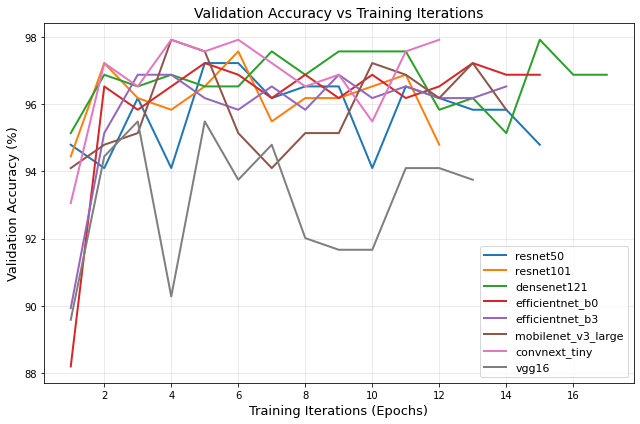

In [8]:
plot_model_accuracy_curves([
    "resnet50",
    "resnet101",
    "densenet121",
    "efficientnet_b0",
    "efficientnet_b3",
    "mobilenet_v3_large",
    "convnext_tiny",
    "vgg16",
])

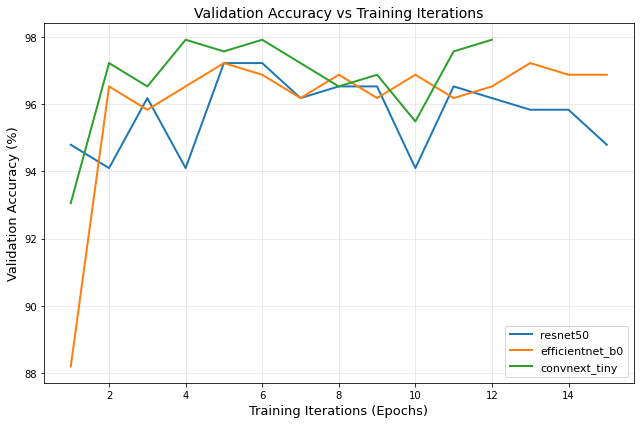

In [9]:
plot_model_accuracy_curves([
    "resnet50",
    "efficientnet_b0",
    "convnext_tiny"
])

In [20]:
#HARD NEGATIVE TESTING

In [21]:
import os
import pandas as pd

TEST_CSV = "splits_final/test.csv"
OUTPUT_SPLIT_DIR = "splits_final"

test_df = pd.read_csv(TEST_CSV)

hard_negative_subclasses = [
    "cloudy",
    "fog",
    "rain",
    "thunderstorm",
    "sandstorm"
]

hard_test_df = test_df[
    (test_df["binary_label"] == 1) |
    ((test_df["binary_label"] == 0) & (test_df["subclass"].isin(hard_negative_subclasses)))
].copy().reset_index(drop=True)

hard_test_csv = os.path.join(OUTPUT_SPLIT_DIR, "hard_negative_test.csv")
hard_test_df.to_csv(hard_test_csv, index=False)

print("Saved hard-negative test set to:", hard_test_csv)
print("Hard-negative test size:", len(hard_test_df))
print(hard_test_df.groupby(["binary_label", "subclass"]).size())

Saved hard-negative test set to: splits_final/hard_negative_test.csv
Hard-negative test size: 281
binary_label  subclass    
0             cloudy           25
              fog              30
              rain             24
              sandstorm        32
              thunderstorm     32
1             tornado         138
dtype: int64


In [22]:
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

HARD_TEST_CSV = "splits_final/hard_negative_test.csv"

top_models = [
    "convnext_tiny",
    "efficientnet_b3",
    "resnet50"
]

hard_test_df = pd.read_csv(HARD_TEST_CSV)
hard_test_dataset = TornadoBinaryDataset(hard_test_df, transform=eval_transform, require_label=True)
hard_test_loader = DataLoader(
    hard_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# same class weight logic as before
train_df = pd.read_csv("splits_final/train.csv")
train_label_counts = train_df["binary_label"].value_counts().to_dict()
num_neg = train_label_counts.get(0, 0)
num_pos = train_label_counts.get(1, 0)
pos_weight_value = num_neg / num_pos if num_pos > 0 else 1.0

hard_results = []

for model_name in top_models:
    print(f"\nEvaluating hard-negative subset: {model_name}")

    model = build_model(model_name).to(DEVICE)
    ckpt_path = os.path.join(BASE_OUTPUT_DIR, model_name, f"best_{model_name}.pth")
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)
    )

    metrics, pred_df = evaluate_labeled(model, hard_test_loader, criterion, DEVICE, threshold=THRESHOLD)

    pred_df.to_csv(os.path.join(BASE_OUTPUT_DIR, model_name, "hard_negative_test_predictions.csv"), index=False)

    row = {
        "model": model_name,
        "hard_test_loss": metrics["loss"],
        "hard_test_accuracy": metrics["accuracy"],
        "hard_test_precision": metrics["precision"],
        "hard_test_recall": metrics["recall"],
        "hard_test_f1": metrics["f1"],
        "hard_test_roc_auc": metrics["roc_auc"],
        "hard_tn_fp_fn_tp": metrics["confusion_matrix"].tolist()
    }
    hard_results.append(row)

hard_results_df = pd.DataFrame(hard_results).sort_values(
    by=["hard_test_f1", "hard_test_roc_auc"], ascending=False
).reset_index(drop=True)

hard_results_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "hard_negative_model_results.csv"), index=False)
hard_results_df


Evaluating hard-negative subset: convnext_tiny

Evaluating hard-negative subset: efficientnet_b3

Evaluating hard-negative subset: resnet50


,model,hard_test_loss,hard_test_accuracy,hard_test_precision,hard_test_recall,hard_test_f1,hard_test_roc_auc,hard_tn_fp_fn_tp
0,resnet50,0.047367,0.982206,0.978417,0.985507,0.981949,0.998936,"[[140, 3], [2, 136]]"
1,convnext_tiny,0.059280,0.971530,0.985075,0.956522,0.970588,0.998378,"[[141, 2], [6, 132]]"
2,efficientnet_b3,0.098602,0.964413,0.977612,0.949275,0.963235,0.995439,"[[140, 3], [7, 131]]"


In [23]:
top_models = [
    "convnext_tiny",
    "efficientnet_b3",
    "resnet50"
]

stress_rows = []

for model_name in top_models:
    stress_path = os.path.join(BASE_OUTPUT_DIR, model_name, "stress_test_predictions.csv")
    stress_df = pd.read_csv(stress_path)

    overall_tornado_rate = (stress_df["pred_label"] == 1).mean()

    for subclass, group in stress_df.groupby("subclass"):
        pred_tornado = int((group["pred_label"] == 1).sum())
        total = len(group)
        pred_tornado_rate = pred_tornado / total if total > 0 else 0.0
        avg_prob = group["pred_prob"].mean()

        stress_rows.append({
            "model": model_name,
            "subclass": subclass,
            "total_samples": total,
            "predicted_as_tornado": pred_tornado,
            "predicted_as_tornado_rate": pred_tornado_rate,
            "avg_pred_prob": avg_prob,
            "overall_stress_tornado_rate": overall_tornado_rate
        })

stress_summary_df = pd.DataFrame(stress_rows).sort_values(
    by=["model", "predicted_as_tornado_rate"], ascending=[True, False]
).reset_index(drop=True)

stress_summary_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "stress_test_summary.csv"), index=False)
stress_summary_df

,model,subclass,total_samples,predicted_as_tornado,predicted_as_tornado_rate,avg_pred_prob,overall_stress_tornado_rate
0,convnext_tiny,waterspout,133,119,0.894737,0.846396,0.837748
1,convnext_tiny,funnelcloud,169,134,0.792899,0.767846,0.837748
2,efficientnet_b3,waterspout,133,119,0.894737,0.859528,0.847682
3,efficientnet_b3,funnelcloud,169,137,0.810651,0.808050,0.847682
4,resnet50,waterspout,133,125,0.939850,0.939916,0.900662
5,resnet50,funnelcloud,169,147,0.869822,0.853641,0.900662


In [24]:
top_models = [
    "convnext_tiny",
    "efficientnet_b3",
    "resnet50"
]

subclass_fp_tables = []

for model_name in top_models:
    path = os.path.join(BASE_OUTPUT_DIR, model_name, "subclass_false_positive_analysis.csv")
    df = pd.read_csv(path)
    df["model"] = model_name
    subclass_fp_tables.append(df)

subclass_fp_comparison_df = pd.concat(subclass_fp_tables, ignore_index=True)
subclass_fp_comparison_df = subclass_fp_comparison_df.sort_values(
    by=["subclass", "false_positive_rate"], ascending=[True, False]
).reset_index(drop=True)

subclass_fp_comparison_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "subclass_fp_comparison.csv"), index=False)
subclass_fp_comparison_df

,subclass,total_non_tornado_samples,false_positives,false_positive_rate,model
0,cloudy,25,2,0.080000,convnext_tiny
1,cloudy,25,2,0.080000,efficientnet_b3
2,cloudy,25,1,0.040000,resnet50
3,fog,30,1,0.033333,resnet50
4,fog,30,0,0.000000,convnext_tiny
5,fog,30,0,0.000000,efficientnet_b3
6,rain,24,0,0.000000,convnext_tiny
7,rain,24,0,0.000000,efficientnet_b3
8,rain,24,0,0.000000,resnet50
9,rainbow,3,0,0.000000,convnext_tiny
